In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('Telco-Customer-Churn.csv')

In [4]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### The colunm 'TotalCharges' have blank value because 'Tenure' is zero .
### so,i replace blanks with zero and convert the datatype of 'TotalCharges' to float 

In [8]:
data['TotalCharges']  = data['TotalCharges'].replace(" ",'0')
data['TotalCharges'] = data['TotalCharges'].astype('float')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
data.duplicated().sum()

0

### converting '0' / '1' values of SwniorCitize to "no" / "yes" to make it easier to understand 

In [15]:
def convert(value):
    if value ==0:
        return "no"
    else :
        return "yes"
    
data['SeniorCitizen'] =data['SeniorCitizen'].apply(convert) 

In [16]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


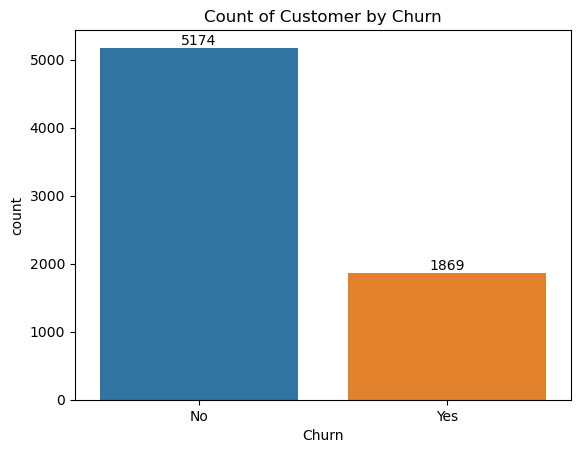

In [27]:
ax=sns.countplot(x='Churn',data=data)
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Churn")
plt.show()

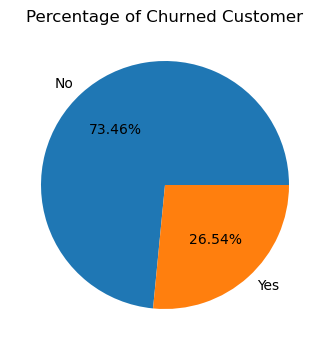

In [37]:
plt.figure(figsize=(4,5))
gb=data.groupby('Churn').agg({"Churn":"count"})
plt.pie(gb['Churn'],labels = gb.index , autopct = '%1.2f%%')
plt.title("Percentage of Churned Customer")
plt.show()

### From the above pie chart we conclude that our 26.54%  customers are churned out. 

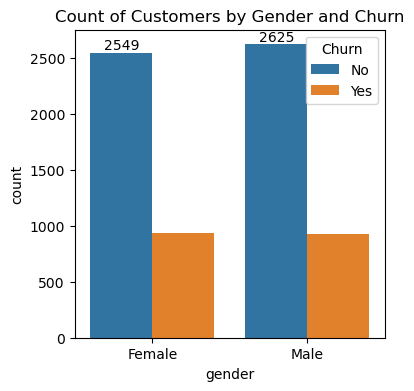

In [45]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x='gender',data=data,hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Gender and Churn")
plt.show()

### From the above graph we conclude that the customers how churned out is not gender specific.

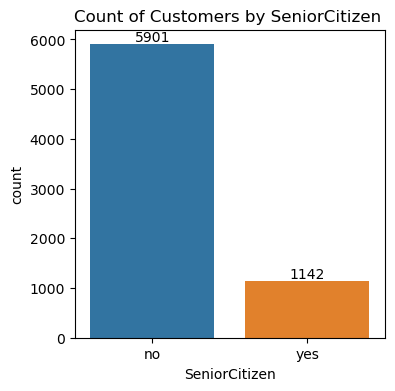

In [66]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x='SeniorCitizen',data=data)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by SeniorCitizen ")
plt.show()


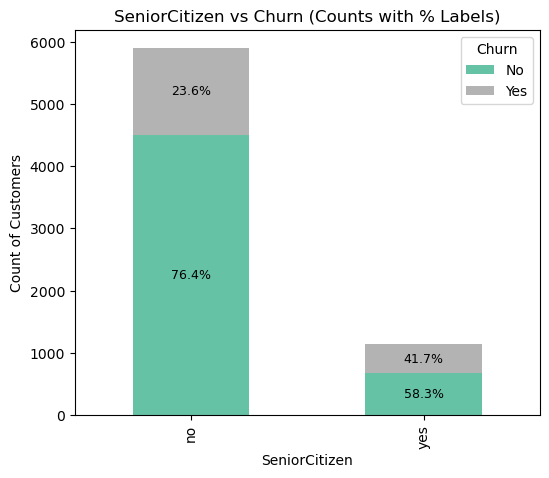

In [53]:
cross_tab = pd.crosstab(data['SeniorCitizen'], data['Churn'])

# Plot stacked bar chart (Y = counts)
ax = cross_tab.plot(
    kind="bar", stacked=True, figsize=(6,5), colormap="Set2"
)

# Add % labels (relative to each bar's total count)
for bars in ax.containers:
    labels = []
    for i, rect in enumerate(bars):
        height = rect.get_height()
        total = cross_tab.iloc[i].sum()  # total per SeniorCitizen group
        if height > 0:
            labels.append(f"{height/total:.1%}")  # percentage only
        else:
            labels.append("")
    ax.bar_label(bars, labels=labels, label_type="center", fontsize=9)

plt.title("SeniorCitizen vs Churn (Counts with % Labels)")
plt.ylabel("Count of Customers")
plt.xlabel("SeniorCitizen")
plt.legend(title="Churn")
plt.show()

### Comparative a greater percentage of customers in SeniorCitizen cetegory have churned.

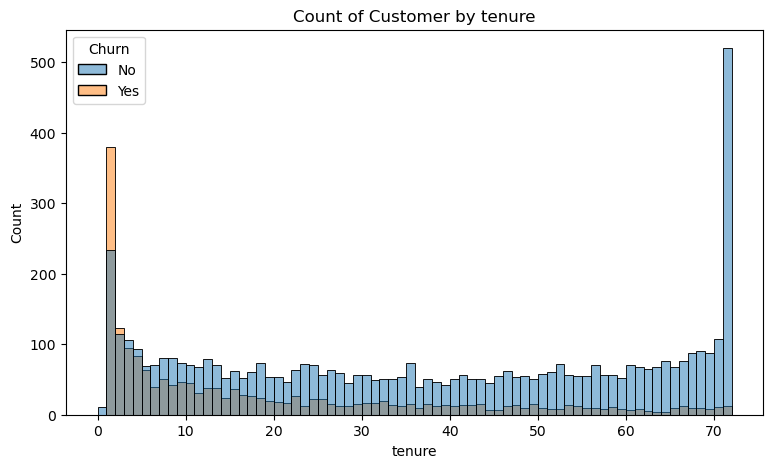

In [78]:
plt.figure(figsize=(9,5))
sns.histplot(data=data,x='tenure',bins = 72,hue='Churn')
plt.title("Count of Customer by tenure")
plt.show()

### Customers who used our service for long time have stayed and customers who used only 1 or 2 months have churned.

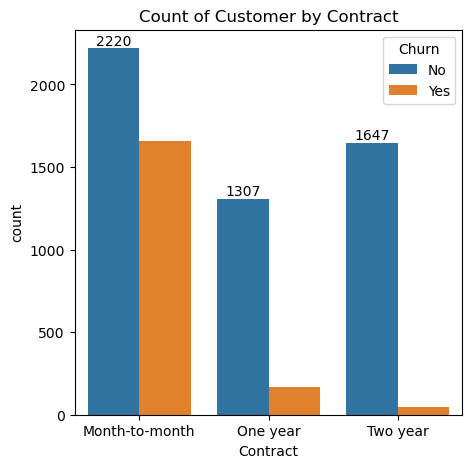

In [79]:
plt.figure(figsize=(5,5))
ax=sns.countplot(data=data,x='Contract',hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Contract")
plt.show()

### Customer who have month-to-month contract are likely to churn then from those who have one year or two year contract

In [83]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

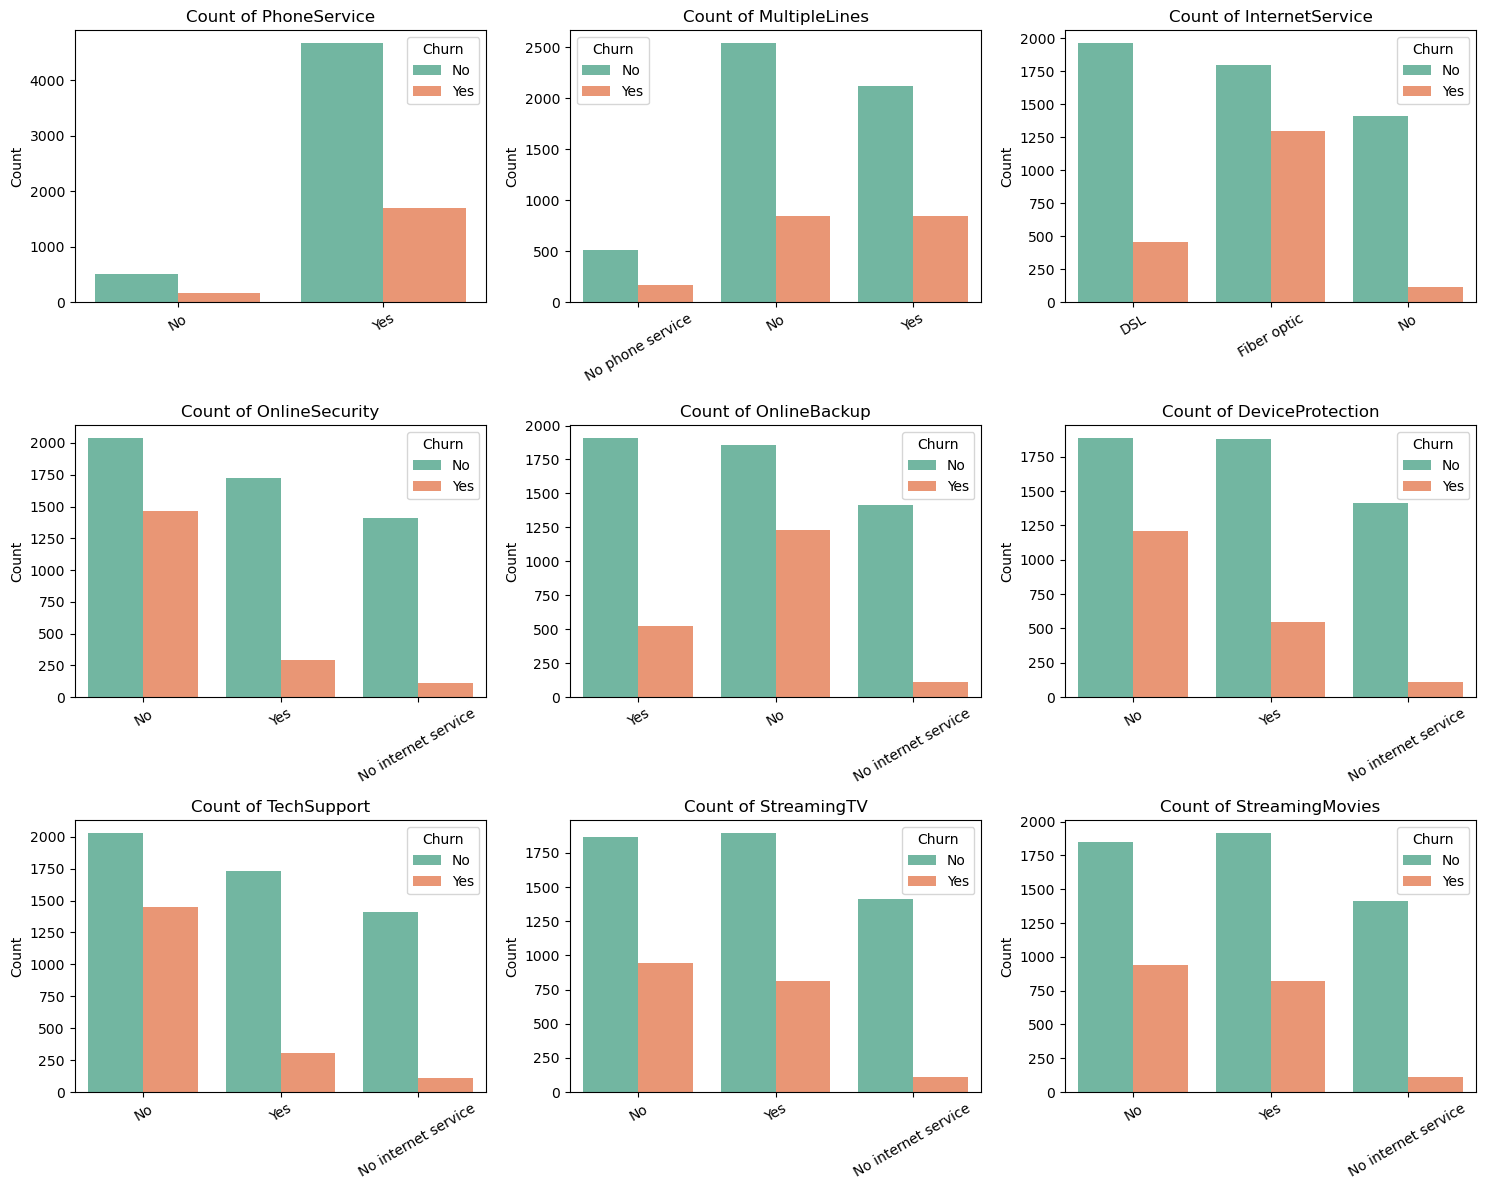

In [86]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Number of subplots
n_cols = 3   # columns per row
n_rows = (len(cols) + n_cols - 1) // n_cols  # rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten()  # flatten 2D axes array

for i, col in enumerate(cols):
    ax = sns.countplot(x=col, data=data,hue='Churn', ax=axes[i], palette="Set2")
    ax.set_title(f"Count of {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    for label in ax.get_xticklabels():
        label.set_rotation(30)  # rotate labels for readability

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [88]:
### Most churn occurs among fiber optic users (~42%) and customers without tech support or security add-ons(35–40%),
### while DSL users (~20%) and those with support/security (~15–18%) churn far less.
### Entertainment services (Streaming TV/Movies) show no impact on churn (~30% each). 
### Targeting add-on adoption and improving fiber optic service quality could significantly reduce overall churn.

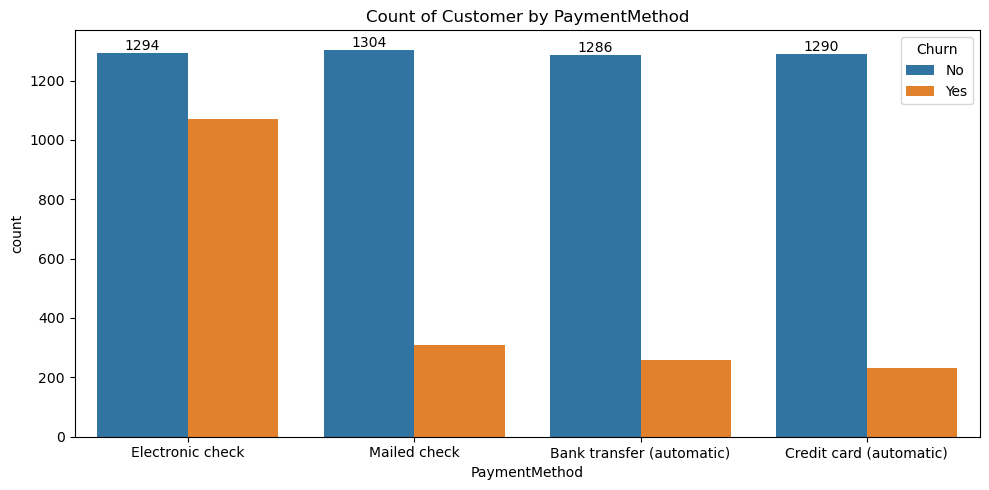

In [93]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=data,x='PaymentMethod',hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customer by PaymentMethod")
plt.tight_layout()
plt.show()

In [94]:
## customers are likely to churn who use Electronic check as paymentmethod.